In [171]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hugomathien/soccer/database.sqlite


# Introdução
Nesta atividade, realizamos o uso de um dataset do futebol europeu para fazer uma classificação com alguns modelos de Machine Learning (ML) como o linear, RBF e o polinomial.

## 1. Importando bibliotecas

In [172]:
import pandas as pd # Pandas para criar os datasets
import sqlite3 as sql # Sqlite3 para pegar os dados do banco de dados sqlite
import seaborn as sns # Seaborn para gerar graficos
import matplotlib.pyplot as plt # Matplotlib para gerar graficos
from sklearn.model_selection import train_test_split, cross_val_score # Para separar os dados de treino e teste, e cross_val para fazer a validação cruzada
from sklearn.pipeline import Pipeline # Para usar um modelo de ML e já fazer a normalização nele
from sklearn.svm import SVC # Para importar os tipos de SVM e usar no Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report # Importando as métricas
from sklearn.preprocessing import StandardScaler # Para normalizar dentro do Pipeline

## 2. Trazendo os dados do dataset

In [173]:
caminho = "/kaggle/input/datasets/hugomathien/soccer/database.sqlite" # Caminho do banco de dados
conn = sql.connect(caminho) # Criando uma conexão com o banco de dados
query = "SELECT * FROM Player_Attributes LIMIT 300;" # Pegando somente as 300 primeiras linhas da tabela dos atributos dos jogadores
df_jogadores = pd.read_sql_query(query, conn) # Criando um dataframe com os dados do banco de dados
conn.close() # Fechando a conexão
print(df_jogadores) # Printando os atributos dos jogadores

      id  player_fifa_api_id  player_api_id                 date  \
0      1              218353         505942  2016-02-18 00:00:00   
1      2              218353         505942  2015-11-19 00:00:00   
2      3              218353         505942  2015-09-21 00:00:00   
3      4              218353         505942  2015-03-20 00:00:00   
4      5              218353         505942  2007-02-22 00:00:00   
..   ...                 ...            ...                  ...   
295  296              186561          75489  2013-03-15 00:00:00   
296  297              186561          75489  2013-03-01 00:00:00   
297  298              186561          75489  2013-02-22 00:00:00   
298  299              186561          75489  2013-02-15 00:00:00   
299  300              186561          75489  2012-08-31 00:00:00   

     overall_rating  potential preferred_foot attacking_work_rate  \
0                67         71          right              medium   
1                67         71          right

## 3. Exploração de dados

In [174]:
df_jogadores.head() # Mostra o topo do dataframe

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67,71,right,medium,medium,49,...,54,48,65,69,69,6,11,10,8,8
1,2,218353,505942,2015-11-19 00:00:00,67,71,right,medium,medium,49,...,54,48,65,69,69,6,11,10,8,8
2,3,218353,505942,2015-09-21 00:00:00,62,66,right,medium,medium,49,...,54,48,65,66,69,6,11,10,8,8
3,4,218353,505942,2015-03-20 00:00:00,61,65,right,medium,medium,48,...,53,47,62,63,66,5,10,9,7,7
4,5,218353,505942,2007-02-22 00:00:00,61,65,right,medium,medium,48,...,53,47,62,63,66,5,10,9,7,7


In [175]:
df_jogadores.shape # Mostra o formato do dataframe

(300, 42)

In [176]:
df_jogadores.info() # Mostra as informações do dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   300 non-null    int64 
 1   player_fifa_api_id   300 non-null    int64 
 2   player_api_id        300 non-null    int64 
 3   date                 300 non-null    object
 4   overall_rating       300 non-null    int64 
 5   potential            300 non-null    int64 
 6   preferred_foot       300 non-null    object
 7   attacking_work_rate  300 non-null    object
 8   defensive_work_rate  300 non-null    object
 9   crossing             300 non-null    int64 
 10  finishing            300 non-null    int64 
 11  heading_accuracy     300 non-null    int64 
 12  short_passing        300 non-null    int64 
 13  volleys              300 non-null    int64 
 14  dribbling            300 non-null    int64 
 15  curve                300 non-null    int64 
 16  free_kic

In [177]:
df_jogadores.describe() # Descreve algumas informações do dataframe

,id,player_fifa_api_id,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,163228.870000,119090.390000,70.283333,75.440000,62.700000,53.973333,55.670000,68.006667,53.203333,...,64.076667,59.536667,50.203333,51.716667,50.156667,11.670000,11.523333,15.896667,13.046667,12.990000
std,86.746758,52702.174751,128203.682099,7.519188,6.535706,15.491394,17.071734,13.818984,11.601232,18.011757,...,15.185722,13.706991,20.678022,21.744404,20.984278,7.226005,6.510305,16.880635,7.223463,7.357332
min,1.000000,17725.000000,23780.000000,47.000000,56.000000,12.000000,15.000000,16.000000,23.000000,14.000000,...,15.000000,28.000000,15.000000,15.000000,12.000000,5.000000,5.000000,5.000000,6.000000,6.000000
25%,75.750000,152747.000000,30572.000000,66.750000,70.000000,57.000000,43.000000,49.750000,64.000000,32.000000,...,58.000000,52.000000,30.000000,29.000000,34.750000,7.000000,7.000000,6.000000,9.000000,10.000000
50%,150.500000,186170.000000,75489.000000,70.000000,76.000000,64.000000,58.000000,58.000000,67.500000,59.000000,...,65.000000,61.000000,56.000000,61.000000,60.000000,12.000000,11.000000,9.000000,11.000000,11.000000
75%,225.250000,189615.000000,162549.000000,77.000000,80.000000,74.250000,67.000000,66.000000,77.000000,68.250000,...,76.000000,69.000000,67.000000,72.000000,68.000000,14.000000,12.000000,13.000000,15.000000,14.000000
max,300.000000,221280.000000,564793.000000,84.000000,90.000000,82.000000,79.000000,82.000000,84.000000,81.000000,...,83.000000,84.000000,82.000000,83.000000,78.000000,53.000000,41.000000,73.000000,51.000000,53.000000


In [178]:
df_jogadores.isnull().sum() # Verifica se tem informações nulas

id                     0
player_fifa_api_id     0
player_api_id          0
date                   0
overall_rating         0
potential              0
preferred_foot         0
attacking_work_rate    0
defensive_work_rate    0
crossing               0
finishing              0
heading_accuracy       0
short_passing          0
volleys                0
dribbling              0
curve                  0
free_kick_accuracy     0
long_passing           0
ball_control           0
acceleration           0
sprint_speed           0
agility                0
reactions              0
balance                0
shot_power             0
jumping                0
stamina                0
strength               0
long_shots             0
aggression             0
interceptions          0
positioning            0
vision                 0
penalties              0
marking                0
standing_tackle        0
sliding_tackle         0
gk_diving              0
gk_handling            0
gk_kicking             0


## 4. Algumas Visualizações

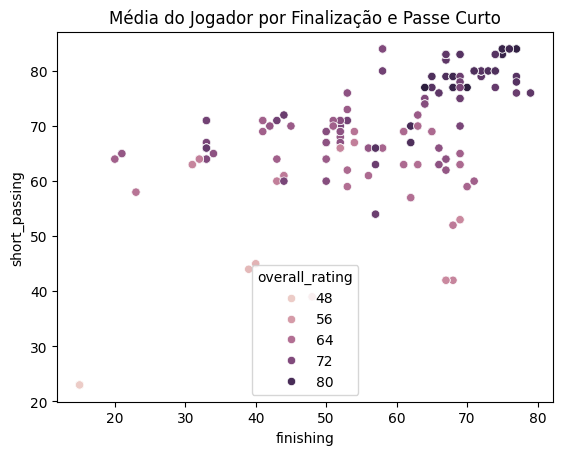

In [179]:
sns.scatterplot( # Usando Seaborn para gerar um grafico de dispersão
    data=df_jogadores,
    x="finishing",
    y="short_passing",
    hue="overall_rating"
)

plt.title("Média do Jogador por Finalização e Passe Curto")
plt.show()

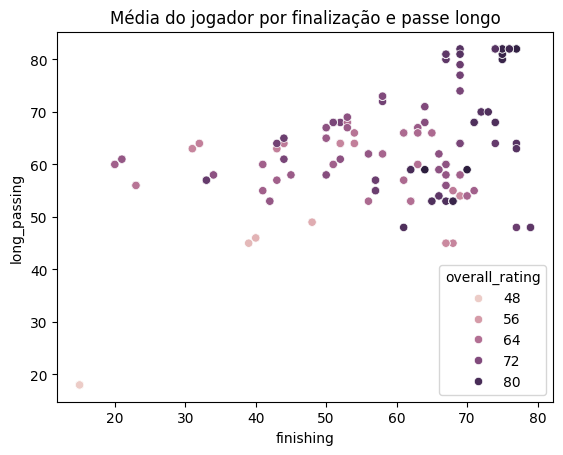

In [180]:
sns.scatterplot( # Usando Seaborn para gerar um grafico de dispersão
    data=df_jogadores,
    x="finishing",
    y="long_passing",
    hue="overall_rating"
)

plt.title("Média do jogador por finalização e passe longo")
plt.show()

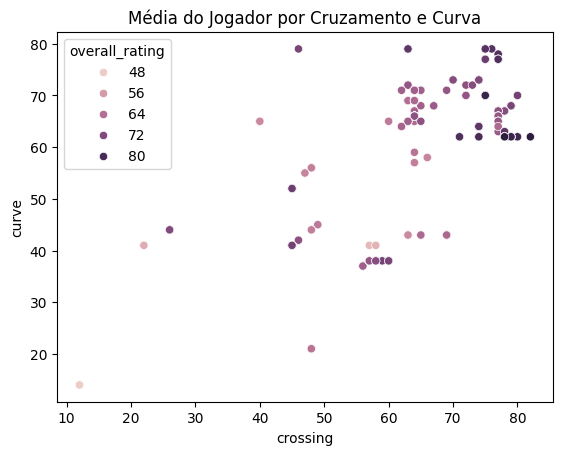

In [181]:
sns.scatterplot( # Usando Seaborn para gerar um grafico de dispersão
    data=df_jogadores,
    x="crossing",
    y="curve",
    hue="overall_rating"
)

plt.title("Média do Jogador por Cruzamento e Curva")
plt.show()

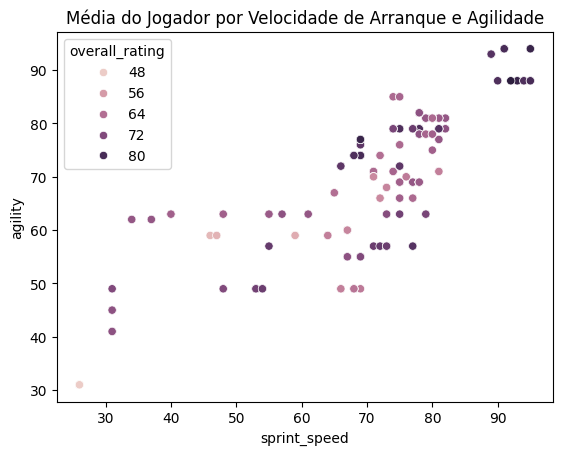

In [182]:
sns.scatterplot( # Usando Seaborn para gerar um grafico de dispersão
    data=df_jogadores,
    x="sprint_speed",
    y="agility",
    hue="overall_rating"
)

plt.title("Média do Jogador por Velocidade de Arranque e Agilidade")
plt.show()

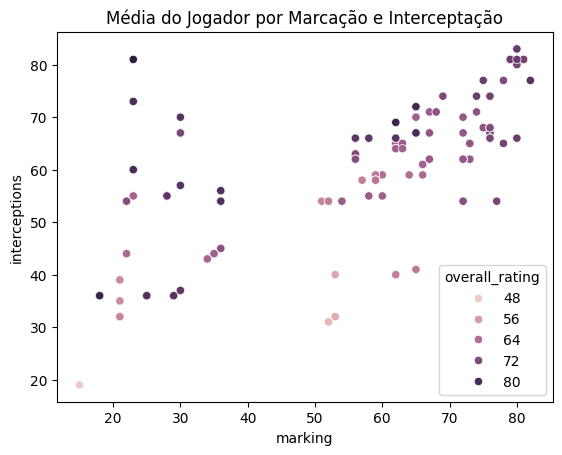

In [183]:
sns.scatterplot( # Usando Seaborn para gerar um grafico de dispersão
    data=df_jogadores,
    x="marking",
    y="interceptions",
    hue="overall_rating"
)

plt.title("Média do Jogador por Marcação e Interceptação")
plt.show()

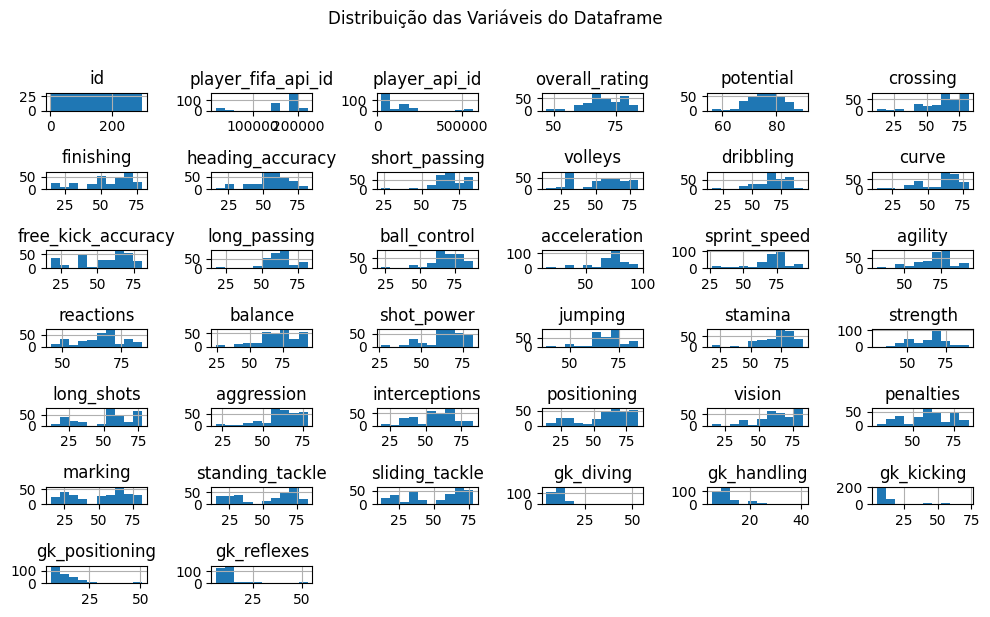

In [184]:
df_jogadores[df_jogadores.columns].hist(figsize=(10, 6)) # Criando graficos de histograma
plt.suptitle("Distribuição das Variáveis do Dataframe", y=1.02)
plt.tight_layout()
plt.show()

## 5. Atribuindo os Valores de Treino e Teste

In [185]:
x = df_jogadores[[ # Features
    'crossing',
    'finishing',
    'heading_accuracy',
    'short_passing',
    'volleys',
    'dribbling',
    'curve',
    'free_kick_accuracy',
    'long_passing',
    'ball_control',
    'acceleration',
    'sprint_speed',
    'agility',
    'reactions',
    'balance',
    'shot_power',
    'jumping',
    'stamina',
    'strength',
    'long_shots',
    'aggression',
    'interceptions',
    'positioning',
    'vision',
    'penalties',
    'marking',
    'standing_tackle',
    'sliding_tackle',
    'gk_diving',
    'gk_handling',
    'gk_kicking',
    'gk_positioning',
    'gk_reflexes'
]]
y = df_jogadores['overall_rating'] # Target
print("Formato de X: ", x.shape)
print("Formato de Y: ", y.shape)

Formato de X:  (300, 33)
Formato de Y:  (300,)


In [186]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42) # Separando os valores para treinar e para testar
# Exibindo quanto foi para Treino e para teste
print("X_train: ", x_train.shape)
print("X_test: ", x_test.shape)
print("Y_train: ", y_train.shape)
print("Y_test: ", y_test.shape)

X_train:  (240, 33)
X_test:  (60, 33)
Y_train:  (240,)
Y_test:  (60,)


## 6. SVM linear

In [187]:
pipeline = Pipeline([
    ("scaler", StandardScaler()), # Normalizando os valores
    ("svm", SVC(kernel="linear", C = 100, random_state = 42)) # Usando o SVM linear
])
pipeline.fit(x_train, y_train)
y_prever = pipeline.predict(x_test)
print("Resultado esperado: ", list(y_test))
print("-------------------------------------------------------------")
print("Resultado obtido: ", (y_prever).tolist())
precisao = accuracy_score(y_test, y_prever) # Calculando a precisão do modelo linear
print("-------------------------------------------------------------")
print(f"Precisão do modelo no SVM linear: {precisao*100:.2f}%")

Resultado esperado:  [72, 59, 79, 73, 60, 65, 64, 72, 74, 48, 61, 65, 65, 69, 69, 65, 78, 71, 78, 82, 70, 77, 71, 70, 75, 68, 81, 77, 79, 63, 70, 82, 51, 69, 68, 78, 73, 69, 70, 67, 72, 68, 79, 65, 68, 59, 62, 61, 75, 60, 69, 60, 63, 67, 77, 82, 74, 72, 67, 69]
-------------------------------------------------------------
Resultado obtido:  [75, 59, 79, 73, 60, 65, 64, 71, 74, 48, 61, 65, 65, 71, 69, 65, 78, 71, 78, 82, 69, 77, 71, 71, 76, 68, 81, 77, 79, 63, 70, 82, 52, 69, 68, 78, 73, 69, 71, 67, 72, 67, 79, 65, 67, 59, 62, 61, 71, 60, 69, 60, 63, 67, 77, 81, 74, 70, 68, 69]
-------------------------------------------------------------
Precisão do modelo no SVM linear: 76.67%


### 6.1 Validação Cruzada do Modelo Linear

In [188]:
validacao_cruzada = cross_val_score(pipeline, x, y, cv = 5) # Realizando a validação cruzada
print("Precisão em cada verificação: ", validacao_cruzada)
print(f"Média: {validacao_cruzada.mean()*100:.2f}%")
print(f"Desvio Padrão: {validacao_cruzada.std()*100:.2f}%")

Precisão em cada verificação:  [0.43333333 0.63333333 0.65       0.58333333 0.33333333]
Média: 52.67%
Desvio Padrão: 12.32%


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


### 6.2 Matriz de Confusão do Modelo Linear

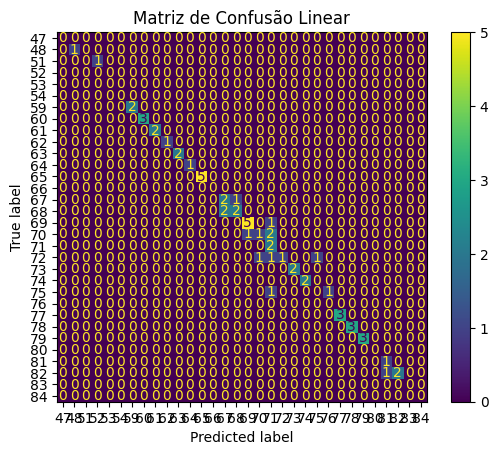

In [189]:
label = sorted(df_jogadores['overall_rating'].unique())
matriz = confusion_matrix(y_test, y_prever, labels=label)
disp = ConfusionMatrixDisplay(confusion_matrix = matriz, display_labels=label)
disp.plot()
plt.title("Matriz de Confusão Linear")
plt.show()

## 7. SVM RBF

In [190]:
pipeline_rbf = Pipeline([
    ("scaler", StandardScaler()), # Normalizando os valores
    ("svm", SVC(kernel="rbf", gamma = 0.1, C = 100, random_state = 42)) # Usando o SVM RBF
])
pipeline_rbf.fit(x_train, y_train)
y_prever_rbf = pipeline_rbf.predict(x_test)
print("Resultado esperado: ", list(y_test))
print("-------------------------------------------------------------")
print("Resultado obtido: ", (y_prever_rbf).tolist())
precisao = accuracy_score(y_test, y_prever_rbf) # Calculando a precisão do modelo RBF
print("-------------------------------------------------------------")
print(f"Precisão do modelo no SVM RBF: {precisao*100:.2f}%")

Resultado esperado:  [72, 59, 79, 73, 60, 65, 64, 72, 74, 48, 61, 65, 65, 69, 69, 65, 78, 71, 78, 82, 70, 77, 71, 70, 75, 68, 81, 77, 79, 63, 70, 82, 51, 69, 68, 78, 73, 69, 70, 67, 72, 68, 79, 65, 68, 59, 62, 61, 75, 60, 69, 60, 63, 67, 77, 82, 74, 72, 67, 69]
-------------------------------------------------------------
Resultado obtido:  [75, 59, 79, 73, 60, 65, 64, 71, 74, 48, 61, 65, 65, 71, 69, 65, 78, 71, 78, 82, 69, 77, 71, 71, 76, 68, 81, 77, 79, 63, 70, 82, 52, 69, 68, 78, 73, 69, 71, 67, 72, 67, 79, 65, 67, 59, 62, 61, 71, 60, 69, 60, 63, 67, 77, 81, 74, 70, 68, 69]
-------------------------------------------------------------
Precisão do modelo no SVM RBF: 76.67%


### 7.1 Validação Cruzada do Modelo RBF

In [191]:
validacao_cruzada = cross_val_score(pipeline_rbf, x, y, cv = 5) # Realizando a validação cruzada
print("Precisão em cada verificação: ", validacao_cruzada)
print(f"Média: {validacao_cruzada.mean()*100:.2f}%")
print(f"Desvio Padrão: {validacao_cruzada.std()*100:.2f}%")

Precisão em cada verificação:  [0.41666667 0.56666667 0.68333333 0.63333333 0.33333333]
Média: 52.67%
Desvio Padrão: 13.19%


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


### 7.2 Matriz de Confusão do Modelo RBF

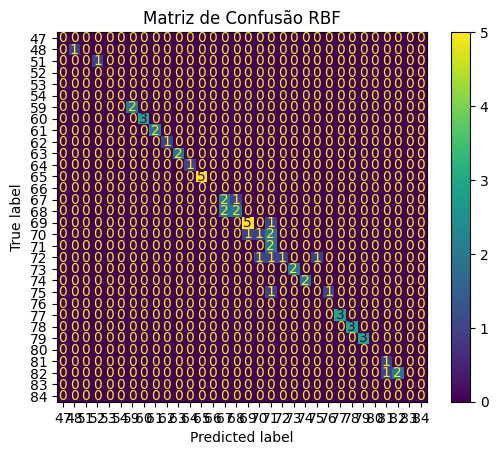

In [192]:
label = sorted(df_jogadores['overall_rating'].unique())
matriz = confusion_matrix(y_test, y_prever_rbf, labels=label)
disp = ConfusionMatrixDisplay(confusion_matrix = matriz, display_labels=label)
disp.plot()
plt.title("Matriz de Confusão RBF")
plt.show()

## 8. SVM Polinomial

In [193]:
pipeline_poly = Pipeline([
    ("scaler", StandardScaler()), # Normalizando os valores
    ("svm", SVC(kernel="poly", degree = 2, C = 1000, random_state = 42)) # Usando o SVM polinomial
])
pipeline_poly.fit(x_train, y_train)
y_prever_poly = pipeline_poly.predict(x_test)
print("Resultado esperado: ", list(y_test))
print("-------------------------------------------------------------")
print("Resultado obtido: ", (y_prever_poly).tolist())
precisao = accuracy_score(y_test, y_prever_poly) # Calculando a precisão do modelo polinomial
print("-------------------------------------------------------------")
print(f"Precisão do modelo no SVM Polinomial: {precisao*100:.2f}%")

Resultado esperado:  [72, 59, 79, 73, 60, 65, 64, 72, 74, 48, 61, 65, 65, 69, 69, 65, 78, 71, 78, 82, 70, 77, 71, 70, 75, 68, 81, 77, 79, 63, 70, 82, 51, 69, 68, 78, 73, 69, 70, 67, 72, 68, 79, 65, 68, 59, 62, 61, 75, 60, 69, 60, 63, 67, 77, 82, 74, 72, 67, 69]
-------------------------------------------------------------
Resultado obtido:  [72, 59, 79, 73, 60, 65, 64, 71, 74, 48, 61, 65, 65, 68, 69, 65, 78, 71, 78, 82, 69, 77, 71, 71, 76, 68, 81, 77, 79, 63, 70, 82, 52, 69, 68, 78, 73, 69, 71, 67, 72, 67, 79, 65, 67, 59, 62, 61, 71, 60, 69, 60, 63, 67, 77, 81, 74, 70, 68, 69]
-------------------------------------------------------------
Precisão do modelo no SVM Polinomial: 78.33%


### 8.1 Validação Cruzada do Modelo Polinomial

In [194]:
validacao_cruzada = cross_val_score(pipeline_poly, x, y, cv = 5) # Realizando a validação cruzada
print("Precisão em cada verificação: ", validacao_cruzada)
print(f"Média: {validacao_cruzada.mean()*100:.2f}%")
print(f"Desvio Padrão: {validacao_cruzada.std()*100:.2f}%")

Precisão em cada verificação:  [0.45       0.55       0.7        0.65       0.33333333]
Média: 53.67%
Desvio Padrão: 13.31%


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


## 8.2 Matriz de Confusão do Modelo Polinomial

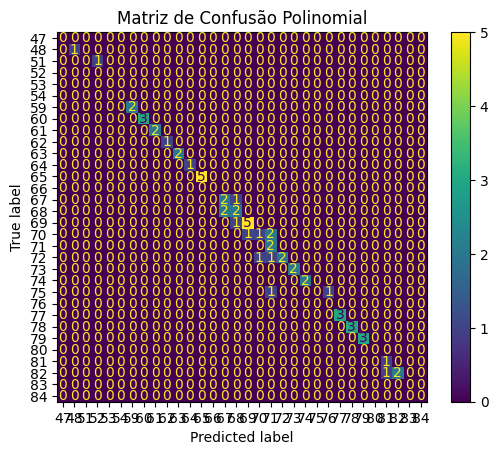

In [195]:
label = sorted(df_jogadores['overall_rating'].unique())
matriz = confusion_matrix(y_test, y_prever_poly, labels=label)
disp = ConfusionMatrixDisplay(confusion_matrix = matriz, display_labels=label)
disp.plot()
plt.title("Matriz de Confusão Polinomial")
plt.show()

## 9. Conclusão

Podemos concluir ao terminar essa atividade que os modelos de Machine Learning conseguiram atingir um bom resultado nas notas dos jogadores, com uma média de acerto de 75%, porém podemos ver ainda que os modelos não obtiveram um resultado satisfatório e ainda precisa de um melhor aprimoramento no futuro para treina-lo melhor e ter melhores resultados. O trabalho teve por objetivo classificar a nota dos jogadores que jogam em ligas europeias e teve uma média de acerto de 75% com a própia avaliação do dataset. 